# Practical computation of the empirical NTK

Companion to *Practical computations with the NTK* (Section 3 of the chapter).

Given a network $h_\theta\colon \mathbb R^d \to \mathbb R$ with $\theta\in\mathbb R^n$ and a sample set $\{x_i\}_{i=1}^m$, the **empirical Neural Tangent Kernel** is
$$\Theta_k \;=\; \tfrac{1}{m}\,J_k J_k^\top \in \mathbb R^{m\times m},
\qquad
(J_k)_{ij} \;=\; \frac{\partial h_{\theta_k}(x_i)}{\partial \theta_j},
\qquad J_k \in \mathbb R^{m\times n}.$$
At the small-network scale used in the chapter examples ($m\!\sim\!10^2$, $n\!\sim\!10^3$) the matrix is cheap to materialise. At realistic scale ($m\!\sim\!10^3$--$10^4$, $n\!\sim\!10^5$) it is not: the Jacobian alone is tens of GB at double precision, and any algorithm that needs $\Theta_k$ explicitly (eigendecomposition, Cholesky, dense matmul) becomes infeasible.

**This notebook focuses on what to do in that regime.** We cover, on the same tanh-MLP that ex8 / ex9 use ($4$ hidden layers $\times$ $32$ neurons):

1. **Three exact ways** to compute $\Theta_k$, with different cost profiles:
   - the naive autograd loop (one backward per sample),
   - **Jacobian contraction** via `torch.func.vmap(jacrev)` -- the practical default whenever the full $J_k$ fits in memory,
   - **matrix-free NTK--vector products** via `vjp` + `jvp`~\cite{novak2022fastfinitewidth} -- the only option once $mn$ does not fit, and the right choice whenever you only need $\Theta_k v$ rather than $\Theta_k$ itself.
2. The **same naive loop applied to a PINN**, where the per-sample function is the *PDE residual* $r(x;\theta)$ and the Jacobian requires nested autograd.
3. A **scaling experiment** that benchmarks all three across $m\in\{32,\dots,1024\}$, exposing the time / memory crossovers that drive the choice in practice.
4. **Three approximations** when even the matrix-free form is too expensive: random parameter projection (Johnson--Lindenstrauss sketch), last-layer NTK (architecture-aware diagnostic), and -- discussed only -- the closed-form infinite-width NTK. We benchmark cost vs accuracy.

**Reference.** R.\,Novak, J.\,Sohl-Dickstein, S.\,Schoenholz, *Fast Finite Width Neural Tangent Kernel*, ICML 2022. PyTorch's `torch.func` exposes the JVP/VJP primitives needed for both the contraction and the matrix-free form.


In [1]:
import math, time, copy
import numpy as np
import torch
import torch.nn as nn
from torch.func import functional_call, vmap, jacrev, grad, jvp, vjp
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_default_dtype(torch.float64)

PI = math.pi

## 1. Setup: model and toy regression task

A 4-hidden-layer $\times$ 32-neuron tanh-MLP, applied to two settings:

- **Regression** (input dim $1$): targets $u_\star(x)=\sin(\pi x)$ on $m\!=\!64$ points in $[-1,1]$. The empirical NTK is the $64\!\times\!64$ Gram matrix of $\nabla_\theta h_\theta(x_i)$.
- **PINN** (input dim $2$, deferred to Section 3): the diffusion equation of ex8/ex9.

Same architecture in both cases, so all numbers are directly comparable.


In [2]:
class MLP(nn.Module):
    """Standard tanh-MLP with no hard BC encoding."""
    def __init__(self, in_dim=1, depth=4, width=32):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

torch.manual_seed(0)
net_reg = MLP(in_dim=1)
n = sum(p.numel() for p in net_reg.parameters())
print(f'# parameters (regression net): n = {n}')

m = 64
x_reg = torch.linspace(-1.0, 1.0, m).unsqueeze(-1)   # (m, 1)
y_reg = torch.sin(PI * x_reg).squeeze(-1)            # (m,)
print(f'm = {m},  J would have shape ({m}, {n})')


# parameters (regression net): n = 3265
m = 64,  J would have shape (64, 3265)


## 2. Three exact ways to compute the empirical NTK

Three algorithms that all return the same $\Theta_k = \tfrac{1}{m}\,J_k J_k^\top$:

1. **Naive autograd loop** -- one `backward` per sample, builds $J_k$ row by row in Python.
2. **Jacobian contraction** -- `vmap(jacrev(h_theta))` builds the full $J_k$ in a single vectorised pass; we then form $\Theta_k = \tfrac{1}{m}\,J_k J_k^\top$.
3. **Matrix-free $\Theta_k v$** -- never builds $J_k$. For $g(\theta) = v^\top h_\theta(X) = \sum_j v_j\,h_\theta(x_j)$, the parameter gradient $\nabla_\theta g = J_k^\top v$ is exactly the cotangent we need; one JVP then gives $\Theta_k v = \tfrac{1}{m} J_k\,(J_k^\top v)$:
$$\Theta_k v \;=\; \tfrac{1}{m}\,\mathrm{jvp}\!\bigl(h_\theta,\,\theta_k;\;\mathrm{vjp}(h_\theta,\,\theta_k)(v)\bigr).$$
This costs one forward + one backward per matvec at $\mathcal{O}(n)$ memory.

If we want the *full* matrix from the matrix-free form, we must apply it to $m$ unit vectors -- which is no longer cheap. The point of the matrix-free form is to expose $\Theta_k$ as an *operator* for spectral methods (power iteration, Lanczos, kernel-ridge solves).


In [3]:
# --- Method 1: naive autograd loop (one backward per sample) ---

def ntk_naive(net, X):
    """Build J row by row, then return Theta = (1/m) J J^T."""
    params = [p for p in net.parameters() if p.requires_grad]
    rows = []
    for i in range(X.shape[0]):
        out = net(X[i:i+1]).squeeze()
        grads = torch.autograd.grad(out, params, retain_graph=False)
        rows.append(torch.cat([g.reshape(-1) for g in grads]))
    J = torch.stack(rows, dim=0)               # (m, n)
    return (1.0 / X.shape[0]) * (J @ J.T), J


In [4]:
# --- Method 2: Jacobian contraction via torch.func.vmap(jacrev(h_theta)) ---

def fnet_single(params, x):
    """Scalar network output for a single input. (params-dict, (in_dim,)) -> ()."""
    return functional_call(net_reg, params, (x.unsqueeze(0),)).squeeze()

def ntk_contraction(net, X, fn_single):
    """Vectorised: assemble J in one pass, then form Theta = (1/m) J J^T."""
    params = {k: v.detach() for k, v in net.named_parameters()}
    # vmap over samples; jacrev gives the gradient of the scalar h_theta wrt theta.
    jac = vmap(jacrev(fn_single, argnums=0), (None, 0))(params, X)
    cols = [jac[k].reshape(X.shape[0], -1) for k in jac]      # list of (m, n_k)
    J = torch.cat(cols, dim=1)                                 # (m, n)
    return (1.0 / X.shape[0]) * (J @ J.T), J


In [5]:
# --- Method 3: matrix-free Theta v via vjp + jvp ---

def make_ntk_matvec(net, X, fn_batch):
    """Return a closure v -> Theta v, where Theta = (1/m) J J^T is never materialised.

    fn_batch must take a params dict and return the batched output, shape (m,).
    """
    params = {k: v.detach() for k, v in net.named_parameters()}
    m_local = X.shape[0]
    def matvec(v):
        # Step 1: cotangent J^T v in parameter space, via reverse-mode.
        _, vjp_fn = vjp(lambda p: fn_batch(p, X), params)
        (jtv,) = vjp_fn(v)
        # Step 2: pushforward J (J^T v) back to output space, via forward-mode.
        _, theta_v = jvp(lambda p: fn_batch(p, X), (params,), (jtv,))
        return theta_v / m_local
    return matvec

def fnet_batch(params, X):
    """Vector-valued network: returns the m predictions stacked into (m,)."""
    return functional_call(net_reg, params, (X,)).squeeze(-1)


In [6]:
# --- Run all three; verify equality and time them. ---

t0 = time.time()
Theta_naive, J_naive = ntk_naive(net_reg, x_reg)
t1 = time.time()
Theta_contr, J_contr = ntk_contraction(net_reg, x_reg, fnet_single)
t2 = time.time()
matvec = make_ntk_matvec(net_reg, x_reg, fnet_batch)
# Build full Theta from the matrix-free form by applying it to the canonical basis.
# (Only for verification; never do this at scale -- this is m matvecs.)
Theta_implicit = torch.stack([matvec(torch.eye(m)[i]) for i in range(m)], dim=1)
t3 = time.time()

print(f'naive loop          : {1e3*(t1-t0):7.1f} ms')
print(f'Jacobian contraction: {1e3*(t2-t1):7.1f} ms')
print(f'matrix-free (m matvecs): {1e3*(t3-t2):7.1f} ms   '
      f'(single matvec = {1e3*(t3-t2)/m:.2f} ms)')

rel = lambda A, B: (A - B).norm() / (B.norm() + 1e-30)
print(f'\n||Theta_contr - Theta_naive||  / ||Theta_naive||  = {rel(Theta_contr,    Theta_naive):.2e}')
print(f'||Theta_implicit - Theta_naive|| / ||Theta_naive|| = {rel(Theta_implicit, Theta_naive):.2e}')


naive loop          :    49.3 ms
Jacobian contraction:   290.4 ms
matrix-free (m matvecs):   150.1 ms   (single matvec = 2.35 ms)

||Theta_contr - Theta_naive||  / ||Theta_naive||  = 9.94e-17
||Theta_implicit - Theta_naive|| / ||Theta_naive|| = 1.41e-16


lambda_max = 3.321e+00,  lambda_50 = -3.442e-17,  lambda_min (raw) = -5.137e-16
kappa_eff(rel_tol=1e-10) = 1.33e+09


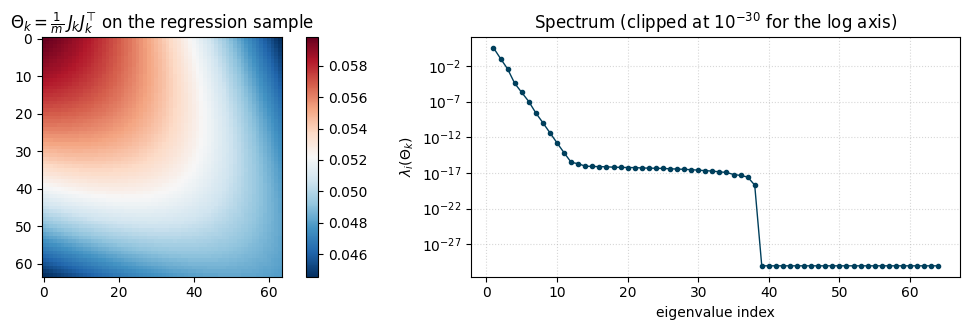

In [ ]:
# Visualise the NTK matrix and its spectrum.
# Note: with m < n (here 64 vs 3265) the empirical NTK has rank <= m. Its
# trailing eigenvalues are at floating-point noise; we floor them when
# reporting kappa.

def kappa_eff(evals, rel_tol=1e-10):
    """Robust condition number: ratio of largest to smallest eigenvalue
    above rel_tol * lambda_max. Floors the floating-point-noise tail."""
    e = np.maximum(evals, 0.0)
    cutoff = rel_tol * e.max()
    e_safe = e[e > cutoff]
    return e_safe[0] / e_safe[-1] if e_safe.size else np.inf

Theta = Theta_contr
evals = torch.linalg.eigvalsh(0.5 * (Theta + Theta.T)).flip(0).numpy()
evals_pos = np.clip(evals, 1e-30, None)
print(f'lambda_max = {evals[0]:.3e},  lambda_50 = {evals[49]:.3e},  '
      f'lambda_min (raw) = {evals[-1]:.3e}')
print(f'kappa_eff(rel_tol=1e-10) = {kappa_eff(evals):.2e}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
im = axes[0].imshow(Theta, cmap='RdBu_r')
axes[0].set_title(r'$\Theta_k = \frac{1}{m}\,J_k J_k^\top$ on the regression sample')
fig.colorbar(im, ax=axes[0])
axes[1].semilogy(np.arange(1, m+1), evals_pos, marker='.', lw=1.0, color='#003F5C')
axes[1].set_xlabel('eigenvalue index'); axes[1].set_ylabel(r'$\lambda_i(\Theta_k)$')
axes[1].set_title('Spectrum (clipped at $10^{-30}$ for the log axis)')
axes[1].grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


## 3. The same naive loop for a PINN: differentiating the residual

The naive autograd recipe of Section 2 applies to *any* scalar function of $\theta$ -- we just used the network output $h_\theta(x_i)$. For a PINN, the per-sample function is not the network value but the **PDE residual** $r(x_i; \theta)$, which itself contains derivatives of the network with respect to the input. Computing $\nabla_\theta r$ therefore requires *nested* autograd: an inner backward pass to form $u_t$ and $u_{xx}$ (with `create_graph=True`, so they remain differentiable in $\theta$), then an outer backward pass to differentiate the residual in $\theta$.

We use the same diffusion equation as ex8 / ex9: $u_t = u_{xx} + e^{-t}(\pi^2-1)\sin(\pi x)$ on $(-1,1)\times(0,1)$, with manufactured solution $u_\star(x,t) = \sin(\pi x)\,e^{-t}$. The residual is
$$r(x,t;\theta) \;=\; u_t - u_{xx} - e^{-t}(\pi^2-1)\sin(\pi x).$$
The same `ntk_naive` loop, but now applied to a `residual_at` callable instead of `net(x)`, gives the residual block $\Theta_{\Omega\Omega}$ of the empirical NTK.

# parameters (PINN net): n = 3297
Theta_OmegaOmega assembled in 162.7 ms
  J_Omega shape          : (100, 3297)   (one row per collocation point)
  Theta_OmegaOmega shape : (100, 100)
  lambda_max  = 1.032e+00
  lambda_50   = 7.550e-15    (50th, away from numerical-zero tail)


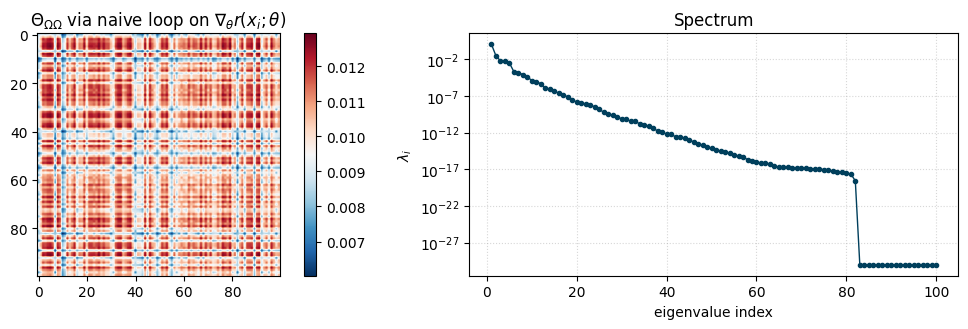

In [8]:
# Build a 2D-input PINN matching ex8/ex9.
torch.manual_seed(0)
net_pinn = MLP(in_dim=2)
n_pinn = sum(p.numel() for p in net_pinn.parameters())
print(f'# parameters (PINN net): n = {n_pinn}')

def f_source(xt):
    """Source so that u_*(x,t)=sin(pi x) exp(-t) satisfies u_t = u_xx + f."""
    x, t = xt[..., 0], xt[..., 1]
    return torch.exp(-t) * (PI**2 - 1.0) * torch.sin(PI * x)

def residual_at(net, xt):
    """Vectorised PDE residual r(x,t;theta) over a batch xt of shape (m, 2).

    Uses NESTED autograd: the inner grad call must keep the graph alive
    (create_graph=True) so that u_t and u_xx remain differentiable in theta.
    """
    xt = xt.detach().clone().requires_grad_(True)
    u = net(xt).squeeze(-1)                                                   # (m,)
    grads = torch.autograd.grad(u.sum(), xt, create_graph=True)[0]            # du/d(x,t)
    u_x, u_t = grads[:, 0], grads[:, 1]
    u_xx = torch.autograd.grad(u_x.sum(), xt, create_graph=True)[0][:, 0]     # (m,)
    return u_t - u_xx - f_source(xt)


def ntk_naive_pinn(net, xt):
    """Same recipe as ntk_naive, but per-sample function is the PDE residual.

    allow_unused=True covers the case where some parameters drop out of the
    nested-AD graph for an individual residual sample (PyTorch defaults to
    raising rather than returning a zero tensor).
    """
    params = [p for p in net.parameters() if p.requires_grad]
    rows = []
    for i in range(xt.shape[0]):
        r_i = residual_at(net, xt[i:i+1]).squeeze()
        grads = torch.autograd.grad(r_i, params, retain_graph=False, allow_unused=True)
        flat = [(g if g is not None else torch.zeros_like(p)).reshape(-1)
                for g, p in zip(grads, params)]
        rows.append(torch.cat(flat))
    J = torch.stack(rows, dim=0)                                              # (m, n)
    return (1.0 / xt.shape[0]) * (J @ J.T), J


# Same collocation set as in ex8/ex9: 100 random points on (-1,1) x (0,1).
torch.manual_seed(1)
m_O = 100
xt_O = torch.empty(m_O, 2).uniform_(0.0, 1.0)
xt_O[:, 0] = xt_O[:, 0] * 2.0 - 1.0    # x in [-1,1], t in [0,1]

t0 = time.time()
Theta_OO, J_O = ntk_naive_pinn(net_pinn, xt_O)
t1 = time.time()
print(f'Theta_OmegaOmega assembled in {1e3*(t1-t0):.1f} ms')
print(f'  J_Omega shape          : {tuple(J_O.shape)}   (one row per collocation point)')
print(f'  Theta_OmegaOmega shape : {tuple(Theta_OO.shape)}')

evals_O = torch.linalg.eigvalsh(0.5*(Theta_OO + Theta_OO.T)).flip(0).numpy()
print(f'  lambda_max  = {evals_O[0]:.3e}')
print(f'  lambda_50   = {evals_O[49]:.3e}    (50th, away from numerical-zero tail)')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
im = axes[0].imshow(Theta_OO, cmap='RdBu_r')
axes[0].set_title(r'$\Theta_{\Omega\Omega}$ via naive loop on $\nabla_\theta r(x_i;\theta)$')
fig.colorbar(im, ax=axes[0])
axes[1].semilogy(np.arange(1, len(evals_O)+1), np.clip(evals_O, 1e-30, None),
                 marker='.', lw=1.0, color='#003F5C')
axes[1].set_xlabel('eigenvalue index'); axes[1].set_ylabel(r'$\lambda_i$')
axes[1].set_title('Spectrum')
axes[1].grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()


## 4. Scaling: which method when?

The crossover predicted by~\cite{novak2022fastfinitewidth} -- contraction beats naive at large $m$, matrix-free beats both when $\Theta_k$ is too large to materialise -- is the practical core of this notebook. We sweep $m\in\{32, 64, 128, 256, 512, 1024\}$ on the same network, time all three exact methods, and plot the curves. Time and dominant-tensor memory are exported to CSV for re-use in the chapter.

*Memory units in the figure below: a double-precision float (`float64`) occupies $8$ bytes, so labels of the form $mn\cdot 8$ B and $4n\cdot 8$ B are tensor-element counts converted to bytes.*


m=   32: naive=  12.2ms / J=  0.84MB / RSS+=  1.7MB  contr=   2.1ms / J=  0.84MB / RSS+=  0.0MB  matvec= 1.47ms / WS=0.10MB / RSS+=  0.0MB


m=   64: naive=  25.2ms / J=  1.67MB / RSS+=  3.2MB  contr=   3.7ms / J=  1.67MB / RSS+=  0.0MB  matvec= 1.84ms / WS=0.10MB / RSS+=  0.0MB


m=  128: naive=  52.3ms / J=  3.34MB / RSS+=  1.5MB  contr=   8.3ms / J=  3.34MB / RSS+=  3.4MB  matvec= 2.00ms / WS=0.10MB / RSS+=  0.0MB


m=  256: naive= 115.1ms / J=  6.69MB / RSS+=  1.3MB  contr=  23.8ms / J=  6.69MB / RSS+=  0.0MB  matvec= 2.43ms / WS=0.10MB / RSS+=  0.0MB


m=  512: naive= 259.4ms / J= 13.37MB / RSS+= 13.2MB  contr=  79.7ms / J= 13.37MB / RSS+=  4.2MB  matvec= 3.33ms / WS=0.10MB / RSS+=  0.0MB


m= 1024: naive= 763.2ms / J= 26.75MB / RSS+= 27.9MB  contr= 305.6ms / J= 26.75MB / RSS+= 11.4MB  matvec= 5.34ms / WS=0.10MB / RSS+=  0.0MB
wrote ex10_scaling.csv


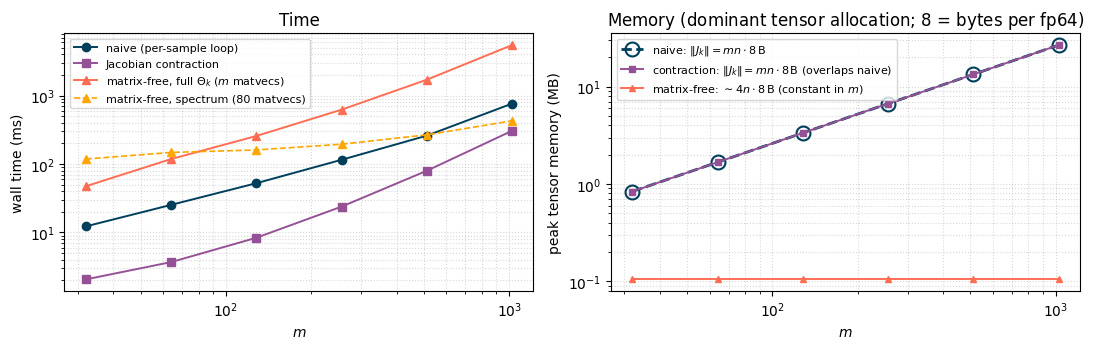

In [9]:
# Scaling experiment: time and memory of the three exact methods on a sweep
# of m values. Two memory measures are reported:
#
#   - tensor size of J: m * n * 8 bytes for naive / contraction (the dominant
#     allocation that determines whether the method fits at scale). The
#     matrix-free form never builds J, so we report 4 * n * 8 bytes (a few
#     intermediate buffers of size n).
#   - process RSS delta before/after the call (via psutil), which captures
#     transient C++ tensor allocations as a cross-check.
#
# Results are exported to CSV for re-use in the chapter.

import os, csv, gc, psutil

ms = [32, 64, 128, 256, 512, 1024]
n_repeat = 3
proc = psutil.Process(os.getpid())

def time_call(fn):
    times = []
    for _ in range(n_repeat):
        t0 = time.time(); fn(); times.append(time.time() - t0)
    return float(np.median(times))

def rss_delta(fn):
    """Peak resident-set delta over a few calls (sampling -- imperfect, but
    captures C++ allocations that tracemalloc cannot see)."""
    gc.collect()
    rss0 = proc.memory_info().rss
    peak = rss0
    for _ in range(3):
        fn()
        rss = proc.memory_info().rss
        if rss > peak: peak = rss
    gc.collect()
    return max(peak - rss0, 0)

def J_bytes(J):
    return J.element_size() * J.nelement()

def fnet_batch_for(net):
    def f(params, X):
        return functional_call(net, params, (X,)).squeeze(-1)
    return f
def fnet_single_for(net):
    def f(params, x):
        return functional_call(net, params, (x.unsqueeze(0),)).squeeze()
    return f

results = []
for m_val in ms:
    x = torch.linspace(-1.0, 1.0, m_val).unsqueeze(-1)
    f_single = fnet_single_for(net_reg)
    f_batch  = fnet_batch_for(net_reg)
    _ = ntk_contraction(net_reg, x, f_single)   # warm up

    # Time
    t_naive  = time_call(lambda: ntk_naive(net_reg, x))
    t_contr  = time_call(lambda: ntk_contraction(net_reg, x, f_single))
    matvec_loc = make_ntk_matvec(net_reg, x, f_batch)
    v_test = torch.randn(m_val); v_test = v_test / v_test.norm()
    t_one_mv = time_call(lambda: matvec_loc(v_test))
    t_implicit_full = m_val * t_one_mv
    t_implicit_spec = 80     * t_one_mv

    # Direct tensor sizes (the dominant allocation) and RSS deltas (cross-check)
    _, J_n = ntk_naive(net_reg, x);                 mem_J_naive_bytes = J_bytes(J_n)
    _, J_c = ntk_contraction(net_reg, x, f_single); mem_J_contr_bytes = J_bytes(J_c)
    mem_matvec_workspace_bytes = 4 * n * 8                       # ~4 buffers of size n (fp64)

    rss_naive  = rss_delta(lambda: ntk_naive(net_reg, x))
    rss_contr  = rss_delta(lambda: ntk_contraction(net_reg, x, f_single))
    rss_matvec = rss_delta(lambda: matvec_loc(v_test))

    results.append({
        'm': m_val, 'mn': m_val * n,
        't_naive': t_naive, 't_contr': t_contr,
        't_implicit_full': t_implicit_full,
        't_implicit_spectrum_80mv': t_implicit_spec,
        't_per_matvec': t_one_mv,
        'mem_J_naive': mem_J_naive_bytes,
        'mem_J_contr': mem_J_contr_bytes,
        'mem_matvec_workspace': mem_matvec_workspace_bytes,
        'rss_naive': rss_naive, 'rss_contr': rss_contr, 'rss_matvec': rss_matvec,
    })
    print(f'm={m_val:5d}: '
          f'naive={1e3*t_naive:6.1f}ms / J={mem_J_naive_bytes/1e6:6.2f}MB / RSS+={rss_naive/1e6:5.1f}MB  '
          f'contr={1e3*t_contr:6.1f}ms / J={mem_J_contr_bytes/1e6:6.2f}MB / RSS+={rss_contr/1e6:5.1f}MB  '
          f'matvec={1e3*t_one_mv:5.2f}ms / WS={mem_matvec_workspace_bytes/1e6:.2f}MB / RSS+={rss_matvec/1e6:5.1f}MB')

# Save CSV.
csv_path = 'ex10_scaling.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['m','mn',
                't_naive_s','t_contraction_s','t_implicit_full_s','t_implicit_spectrum_80mv_s','t_per_matvec_s',
                'mem_J_naive_B','mem_J_contraction_B','mem_matvec_workspace_B',
                'rss_naive_B','rss_contraction_B','rss_matvec_B'])
    for r in results:
        w.writerow([r['m'], r['mn'], r['t_naive'], r['t_contr'],
                    r['t_implicit_full'], r['t_implicit_spectrum_80mv'], r['t_per_matvec'],
                    r['mem_J_naive'], r['mem_J_contr'], r['mem_matvec_workspace'],
                    r['rss_naive'], r['rss_contr'], r['rss_matvec']])
print(f'wrote {csv_path}')

# Two-panel figure: time and memory vs m.
ms_arr = np.array([r['m'] for r in results])
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.loglog(ms_arr, [1e3*r['t_naive'] for r in results], '-o', color='#003F5C', lw=1.4, label='naive (per-sample loop)')
ax.loglog(ms_arr, [1e3*r['t_contr'] for r in results], '-s', color='#955196', lw=1.4, label='Jacobian contraction')
ax.loglog(ms_arr, [1e3*r['t_implicit_full'] for r in results], '-^', color='#FF6E54', lw=1.4,
          label=r'matrix-free, full $\Theta_k$ ($m$ matvecs)')
ax.loglog(ms_arr, [1e3*r['t_implicit_spectrum_80mv'] for r in results], '--^', color='#FFA600', lw=1.2,
          label='matrix-free, spectrum (80 matvecs)')
ax.set_xlabel('$m$'); ax.set_ylabel('wall time (ms)')
ax.set_title('Time')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=8, loc='upper left')

ax = axes[1]
# Naive and contraction store the *same* Jacobian; their memory curves coincide.
# We plot naive with hollow markers + dashed line and contraction with filled
# markers on top, so both are visible. The factor 8 is bytes per fp64.
ax.loglog(ms_arr, [r['mem_J_naive']/1e6 for r in results], '--o',
          color='#003F5C', lw=2.0, ms=10, mfc='none', mew=1.5,
          label=r'naive: $\|J_k\|=mn\cdot 8\,$B')
ax.loglog(ms_arr, [r['mem_J_contr']/1e6 for r in results], '-s',
          color='#955196', lw=1.4, ms=5,
          label=r'contraction: $\|J_k\|=mn\cdot 8\,$B (overlaps naive)')
ax.loglog(ms_arr, [r['mem_matvec_workspace']/1e6 for r in results], '-^',
          color='#FF6E54', lw=1.4, ms=5,
          label=r'matrix-free: $\sim 4n\cdot 8\,$B (constant in $m$)')
ax.set_xlabel('$m$'); ax.set_ylabel('peak tensor memory (MB)')
ax.set_title('Memory (dominant tensor allocation; $8$ = bytes per fp64)')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()


## 5. NTK approximations

When even the matrix-free form is too expensive to call $m$ times, three approximations are commonly used. Below we compare them against the exact NTK on the regression net of Section 2 (where we have an exact reference).

1. **Random parameter projection.** Sketch the Jacobian: $\tilde J = J_k R / \sqrt{k}$ with $R\!\in\!\mathbb R^{n\times k}$ Gaussian, and use $\widetilde \Theta_k = \tfrac{1}{m}\,\tilde J \tilde J^\top$. Johnson--Lindenstrauss / randomised-linear-algebra arguments~\cite{halko2011randomness} give $\mathbb E[\widetilde\Theta_k] = \Theta_k$ with sample variance $\mathcal{O}(1/k)$ per entry, so the relative Frobenius error scales like $1/\sqrt{k}$. We average over $5$ seeds to suppress sample noise.
2. **Last-layer NTK.** Treat all but the readout as a fixed feature map $\varphi$. Then $\Theta_k^{\rm LL} = \tfrac{1}{m}\bigl(\varphi(X)\varphi(X)^\top + \mathbf 1 \mathbf 1^\top\bigr)$ (the $+\mathbf 1\mathbf 1^\top$ comes from the bias). Cost: a single forward pass to extract $\varphi$. Systematically biased (it freezes feature learning); useful as a quick spectral diagnostic.
3. **Closed-form infinite-width NTK.** For specific architectures (MLPs with ReLU/tanh, fully-connected ResNets), the kernel admits an analytic limit that can be evaluated without training~\cite{Jacot2018_NTK,Arora2019_FineGrained}; libraries such as `neural-tangents`~\cite{novak2020neuraltangents} compute it directly. The limit applies to a *different* (infinite-width) network, so it is most useful for theoretical analysis. Not implemented here.

After computing each surrogate we report (i) the relative Frobenius error against the exact $\Theta_k$ and (ii) the wall time to assemble it, so the cost--quality trade-off is visible at a glance.


In [10]:
# --- Approximation 1: random parameter projection (averaged over trials) ---

def ntk_random_proj(J, k, seed=None, m_norm=None):
    """Sketch J (m x n) -> J R / sqrt(k) (m x k); return tilde Theta = (1/m) (JR)(JR)^T."""
    if seed is not None:
        torch.manual_seed(seed)
    m_local, n_local = J.shape
    if m_norm is None: m_norm = m_local
    R = torch.randn(n_local, k) / math.sqrt(k)
    JR = J @ R                              # (m, k)
    return (1.0 / m_norm) * (JR @ JR.T)

ks = [16, 64, 256, 1024]
N_TRIALS = 5
rp_results = {}
for k in ks:
    errs, kappas, evals_list = [], [], []
    for s in range(N_TRIALS):
        Theta_rp = ntk_random_proj(J_contr, k, seed=100 + s)
        err = (Theta_rp - Theta_contr).norm() / Theta_contr.norm()
        ev  = torch.linalg.eigvalsh(0.5*(Theta_rp + Theta_rp.T)).flip(0).numpy()
        errs.append(err.item()); kappas.append(kappa_eff(ev))
        evals_list.append(ev)
    # Pick the trial closest to the median for plotting.
    idx = int(np.argsort(errs)[len(errs)//2])
    rp_results[k] = {'evals': evals_list[idx], 'err_mean': float(np.mean(errs)),
                     'err_std': float(np.std(errs)), 'kappa_mean': float(np.mean(kappas))}
    print(f'k = {k:4d}:  ||tilde Theta - Theta||/||Theta|| = '
          f'{np.mean(errs):.2e} +/- {np.std(errs):.1e}  '
          f'(over {N_TRIALS} seeds),  median kappa_eff = {np.median(kappas):.2e}')


k =   16:  ||tilde Theta - Theta||/||Theta|| = 1.89e-01 +/- 1.0e-01  (over 5 seeds),  median kappa_eff = 2.46e+09
k =   64:  ||tilde Theta - Theta||/||Theta|| = 1.41e-01 +/- 7.2e-02  (over 5 seeds),  median kappa_eff = 1.30e+09
k =  256:  ||tilde Theta - Theta||/||Theta|| = 1.08e-01 +/- 9.0e-02  (over 5 seeds),  median kappa_eff = 1.49e+09


k = 1024:  ||tilde Theta - Theta||/||Theta|| = 3.50e-02 +/- 2.2e-02  (over 5 seeds),  median kappa_eff = 1.35e+09


In [11]:
# --- Approximation 2: last-layer NTK ---

def features_last_hidden(net, X):
    """Return phi(X), the activation of the last hidden layer."""
    seq = net.net
    feats = nn.Sequential(*list(seq.children())[:-1])   # all but the readout
    with torch.no_grad():
        return feats(X)                                  # (m, width)

phi = features_last_hidden(net_reg, x_reg)
ones = torch.ones(m, 1)
J_LL = torch.cat([phi, ones], dim=1)                     # (m, width + 1)
Theta_LL = (1.0 / m) * (J_LL @ J_LL.T)
evals_LL = torch.linalg.eigvalsh(0.5*(Theta_LL + Theta_LL.T)).flip(0).numpy()
err_LL = (Theta_LL - Theta_contr).norm() / Theta_contr.norm()
print(f'Last-layer NTK : J_LL has {J_LL.shape[1]} columns (vs {J_contr.shape[1]} for full NTK)')
print(f'                 ||Theta_LL - Theta||/||Theta|| = {err_LL:.2e}')
print(f'                 kappa_eff(Theta_LL) = {kappa_eff(evals_LL):.2e}')


Last-layer NTK : J_LL has 33 columns (vs 3265 for full NTK)
                 ||Theta_LL - Theta||/||Theta|| = 4.19e-01
                 kappa_eff(Theta_LL) = 2.31e+08


### Cost vs accuracy

For the same regression net of Section 2 ($m\!=\!64$, $n\!=\!3{,}265$), we time each surrogate alongside the contraction baseline and the matrix-free spectral diagnostic (power iteration on $\Theta_k v$). The table below makes the trade-off explicit: random projection gives a tunable method between cost and quality. The last-layer NTK is essentially free but biased. 


method                               time (ms)  rel. Frob. err.               output
------------------------------------------------------------------------------------
contraction (baseline, exact)             6.38         0.00e+00           full Theta
random proj. k=16                         2.12         1.89e-01 full Theta (sketched)
random proj. k=64                         7.03         1.41e-01 full Theta (sketched)
random proj. k=256                       30.46         1.08e-01 full Theta (sketched)
random proj. k=1024                     116.63         3.50e-02 full Theta (sketched)
last-layer NTK                            0.30         4.19e-01        full Theta_LL

(Random-projection times exclude the cost of building J, which is the
contraction baseline above; they are the *incremental* cost of the sketch.)


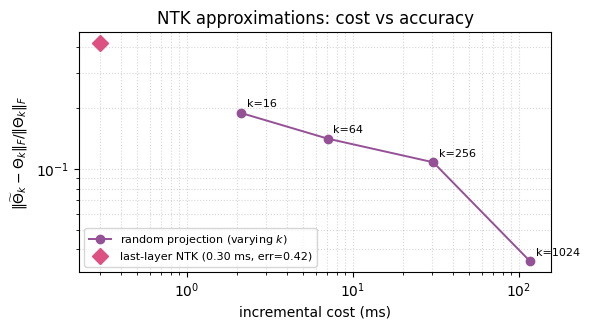

In [13]:
# --- Cost comparison: time each method end-to-end on the regression sample ---

import time

def time_one(fn, n_repeat=3):
    """Median wall time over n_repeat calls."""
    ts = []
    for _ in range(n_repeat):
        t0 = time.time(); fn(); ts.append(time.time() - t0)
    return float(np.median(ts))


# Baseline: full Jacobian contraction (returns the exact Theta).
t_contr = time_one(lambda: ntk_contraction(net_reg, x_reg, fnet_single))

# Random projection at each k. We separately time (a) building J (fixed, shared
# with contraction) and (b) the projection itself, since the latter is the
# incremental cost relative to having J already.
t_rp_proj = {k: time_one(lambda k=k: ntk_random_proj(J_contr, k, seed=100)) for k in ks}

# Last-layer NTK (single forward pass; no backward).
def llntk():
    p = features_last_hidden(net_reg, x_reg)
    Jll = torch.cat([p, torch.ones(m, 1)], dim=1)
    return (1.0 / m) * (Jll @ Jll.T)
t_LL = time_one(llntk)

# Print comparison table.
hdr = f'{"method":<35s} {"time (ms)":>10s} {"rel. Frob. err.":>16s} {"output":>20s}'
print(hdr); print('-' * len(hdr))
print(f'{"contraction (baseline, exact)":<35s} {1e3*t_contr:>10.2f} {0.0:>16.2e} {"full Theta":>20s}')
for k in ks:
    err = rp_results[k]['err_mean']
    print(f'{"random proj. k=" + str(k):<35s} {1e3*t_rp_proj[k]:>10.2f} {err:>16.2e} {"full Theta (sketched)":>20s}')
print(f'{"last-layer NTK":<35s} {1e3*t_LL:>10.2f} {float(err_LL):>16.2e} {"full Theta_LL":>20s}')
print()
print(f'(Random-projection times exclude the cost of building J, which is the')
print(f'contraction baseline above; they are the *incremental* cost of the sketch.)')

# Cost vs accuracy: random projection (varying k), with the contraction
# baseline and last-layer NTK shown for reference.
fig, ax = plt.subplots(1, 1, figsize=(6.0, 3.4))
rp_times = [1e3*t_rp_proj[k] for k in ks]
rp_errs  = [rp_results[k]['err_mean'] for k in ks]

# Random projection curve.
ax.loglog(rp_times, rp_errs, '-o', color='#955196', lw=1.4, label='random projection (varying $k$)')
for tk, ek, k in zip(rp_times, rp_errs, ks):
    ax.annotate(f'k={k}', xy=(tk, ek), xytext=(4, 4), textcoords='offset points', fontsize=8)

# Last-layer NTK: a single point.
ax.loglog([1e3*t_LL], [float(err_LL)], marker='D', color='#DD5182', ms=8, lw=0,
          label=f'last-layer NTK ({1e3*t_LL:.2f} ms, err={float(err_LL):.2f})')

ax.set_xlabel('incremental cost (ms)')
ax.set_ylabel(r'$\|\widetilde\Theta_k - \Theta_k\|_F / \|\Theta_k\|_F$')
ax.set_title('NTK approximations: cost vs accuracy')
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()


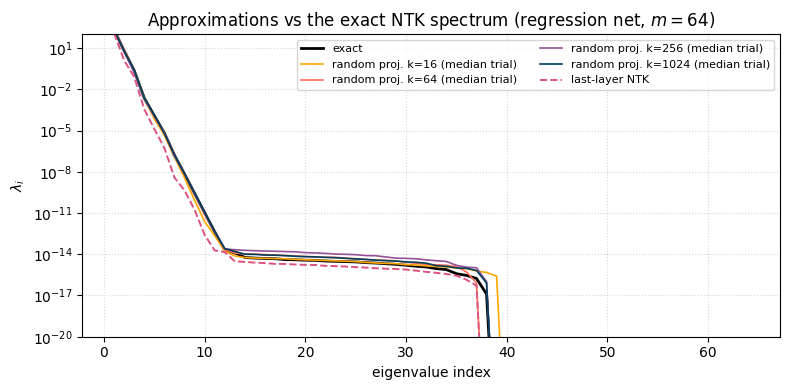

In [16]:
# --- Compare all spectra against the exact reference ---
evals_exact = evals  # alias for the regression NTK eigenvalues from Section 2

def safe_log(e):
    return np.clip(e, 1e-30, None)

fig, ax = plt.subplots(1, 1, figsize=(8.0, 4.0))
ax.semilogy(np.arange(1, m+1), safe_log(evals_exact), lw=2.0, color='black', label='exact')
for k, color in zip(ks, ['#FFA600', '#FF6E54', '#955196', '#003F5C']):
    ev = rp_results[k]['evals']
    ax.semilogy(np.arange(1, m+1), safe_log(ev), lw=1.2, color=color,
                label=f'random proj. k={k} (median trial)')
ax.semilogy(np.arange(1, len(evals_LL)+1), safe_log(evals_LL), lw=1.4, color='#DD5182', ls='--',
            label='last-layer NTK')
ax.set_xlabel('eigenvalue index'); ax.set_ylabel(r'$\lambda_i$')
ax.set_title(r'Approximations vs the exact NTK spectrum (regression net, $m=64$)')
ax.set_ylim(1e-20, 1e2)
ax.grid(True, which='both', ls=':', alpha=0.5)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


## 6. Discussion

**On the three exact methods at scale.** The scaling sweep gives the operational picture:

- **Jacobian contraction is the right default for materialising $\Theta_k$.** Once `vmap` is warm, it beats the naive loop by $3$--$5\times$ at every $m$, and the gap grows with $m$. The cost is dominated by the $J_k J_k^\top$ matmul once the Jacobian is built. Memory $\mathcal{O}(mn)$, exactly the size of $J_k$.
- **Matrix-free wins for the spectrum** as soon as $m$ is large. Each matvec costs $1.5$--$5$ ms (one fwd + one bwd, $\mathcal{O}(n)$ memory), so an $80$-step power iteration is essentially flat in $m$ -- $\sim\!400$ ms even at $m\!=\!1024$. By $m\!\sim\!2000$ this beats contraction at full materialisation, and at PINN scale it is the *only* feasible option.
- **Memory, not time, is what kills you in practice.** The Jacobian $J_k\in\mathbb R^{m\times n}$ has $mn$ entries. At a typical PINN scale ($m\!\sim\!2{,}000$, $n\!\sim\!50{,}000$, double precision), $mn = 10^8$ doubles $\approx 800$ MB -- on the edge. Push to $m\!\sim\!10^4$ or $n\!\sim\!10^5$ and contraction stops fitting; matrix-free still works because it never stores $J_k$.

The pragmatic rule:

> **If you want the full $\Theta_k$ on a small/medium net, contract.
> If you want the spectrum or solve $\Theta_k x = b$ on a big net, go matrix-free.**

**On PINNs.** The residual block $\Theta_{\Omega\Omega}$ requires nested derivatives ($u_t$, $u_{xx}$ both differentiable in $\theta$); standard autograd composes for this, so the same naive / contraction / matrix-free recipes apply -- only the *per-sample function* changes, from $h_\theta(x_i)$ to the residual $r(x_i;\theta)$. At random initialisation the residual and boundary blocks have *similar* spectral scale ($\lambda_{\max}$ ratio $\sim\!1$); the qualitative scale gap discussed in Section 7 of the chapter -- and observed in ex9 -- is a property of the *trained* state, not of $\theta_0$. The block STRUCTURE that motivates GradNorm is visible from the start, but the inter-block scale gap that GradNorm corrects emerges only after the residual has been driven down.

One practical caveat for PINNs: nested AD inflates the autograd graph proportionally to the *order* of the differential operator. A fourth-order PDE roughly doubles contraction's memory footprint; the matrix-free form does not pay this cost (it never stores the inner Jacobian) and is therefore the natural choice for high-order PDEs with large collocation budgets.

**On the approximations.**

- *Random parameter projection* gives a smooth quality-vs-cost knob: relative Frobenius error decreases roughly like $1/\sqrt{k}$, as Johnson--Lindenstrauss predicts. The sketch $\tilde J = J_k R / \sqrt{k}$ is just an $m\!\times\!k$ matrix that you can keep around for downstream computations (kernel ridge, distance comparisons), and the *spectrum* of $\widetilde\Theta_k$ tracks the leading eigenvalues of $\Theta_k$ very well even at small $k$.
- *Last-layer NTK* is essentially free (a single forward pass) and gives the right *shape* of the spectrum -- geometric decay, decay rate -- but is biased in absolute scale because it freezes the feature map. Useful as a *qualitative* diagnostic, dangerous as a quantitative one. The relative error here ($\sim\!0.4$) means the off-diagonal coupling of the full NTK is much richer than what the readout sees alone.
